# Laboratorio 3. Preprocesamiento de las imagenes

Fabian Prado Dluzniewski 23427

Abby Donis 22440

Hansel Lopez 19026

Este notebook cubre el ejercicio 3. Documenta y justifica cada transformacion
aplicada a las imagenes antes de entrenar, y deja los tensores listos para los
modelos.

Parte de la division guardada por `01_EDA.ipynb` en `data/division.csv`, asi que
ese notebook debe correrse primero.

### IMPORTS

In [1]:
import logging
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image, ImageFilter, ImageOps
from torch.utils.data import DataLoader, Dataset

import kagglehub

logging.getLogger("kagglehub").setLevel(logging.CRITICAL)
plt.style.use("seaborn-v0_8-whitegrid")

c:\Users\abbyd\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### CONFIGURACION

In [2]:
DATASET = "grassknoted/asl-alphabet"
LADO = 64
SEMILLA = 42

DIR_DATOS = Path("./data")
DIR_PROC = DIR_DATOS / "procesado"
DIR_PROC.mkdir(parents=True, exist_ok=True)

torch.manual_seed(SEMILLA)
np.random.seed(SEMILLA)

DISPOSITIVO = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"dispositivo: {DISPOSITIVO}")

CLASES = [chr(c) for c in range(ord("A"), ord("Z") + 1)] + ["space", "del", "nothing"]
IDX_CLASE = {c: i for i, c in enumerate(CLASES)}

division = pd.read_csv(DIR_DATOS / "division.csv")
print(f"registros en la division: {len(division):,}")
print(division.groupby("grupo").size().to_string())

dispositivo: cpu
registros en la division: 17,400
grupo
test      2610
train    12180
val       2610


## 3.1. Submuestra y justificacion

El dataset completo tiene 87,000 imagenes de 200x200 a color. Entrenar varias
arquitecturas sobre esa cantidad no cabe en el tiempo del laboratorio, y el
enunciado autoriza trabajar con una submuestra.

Se usan 600 imagenes por clase, 17,400 en total, dentro del rango de 500 a 800
que sugiere el enunciado. La eleccion responde a tres razones.

Primero, el dataset esta perfectamente balanceado, asi que tomar la misma
cantidad por clase conserva esa propiedad y no introduce sesgo.

Segundo, el analisis exploratorio mostro que las imagenes consecutivas de una
clase son cuadros contiguos del mismo video y por lo tanto casi identicas. La
informacion nueva por imagen adicional decae rapido, de modo que pasar de 600 a
3,000 por clase aporta mucho menos de lo que sugiere el conteo.

Tercero, la submuestra se tomo al azar sobre el rango completo de cada clase y
no en bloques contiguos, con lo que cubre toda la sesion de grabacion y toda su
variacion de iluminacion y distancia.

## 3.2. Reduccion de resolucion

Se baja de 200x200 a 64x64. La comparacion visual sirve para confirmar que la
pose de la mano sigue siendo distinguible al tamano elegido.

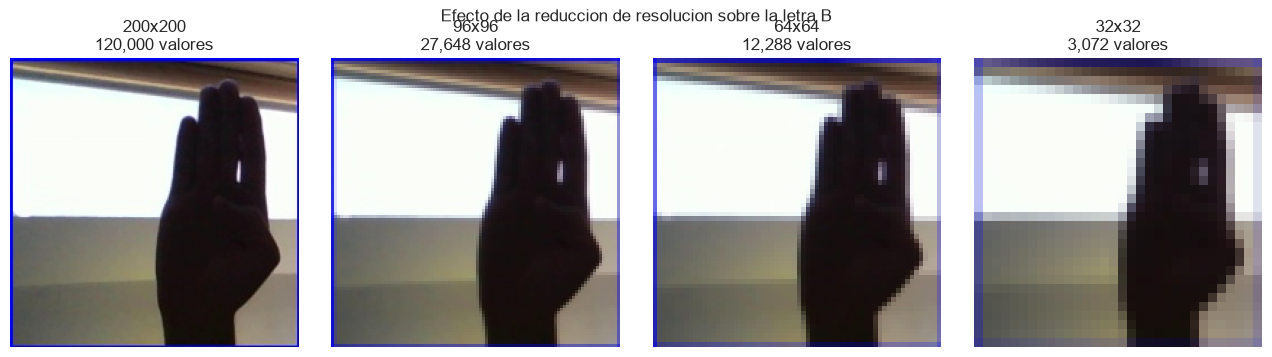

reduccion de datos de 200 a 64: 89.8 por ciento menos valores por imagen


In [3]:
RAIZ = Path(kagglehub.dataset_download(DATASET))
ejemplo = Image.open(division.loc[division["clase"] == "B", "ruta"].iloc[0])

tamanos = [200, 96, 64, 32]
fig, axes = plt.subplots(1, len(tamanos), figsize=(13, 3.6))
for ax, lado in zip(axes, tamanos):
    ax.imshow(ejemplo.resize((lado, lado), Image.BILINEAR))
    ax.set_title(f"{lado}x{lado}\n{lado*lado*3:,} valores")
    ax.axis("off")
fig.suptitle("Efecto de la reduccion de resolucion sobre la letra B", fontsize=12)
plt.tight_layout()
plt.show()

print(f"reduccion de datos de 200 a {LADO}: "
      f"{(1 - (LADO**2)/(200**2))*100:.1f} por ciento menos valores por imagen")

A 64x64 la silueta de la mano y la separacion entre dedos siguen siendo
legibles. A 32x32 los dedos empiezan a fundirse, que es justo la informacion
que distingue los grupos confundibles como U y V. Por eso 64 es el punto donde
se gana velocidad sin perder lo que el problema necesita.

La interpolacion es bilineal. Al reducir tamano evita el aliasing que produce
el vecino mas cercano, sin el costo de metodos de mayor orden.

## 3.3. Filtros evaluados

Se comparan cuatro tratamientos sobre la misma imagen para decidir cuales
entran al pipeline final.

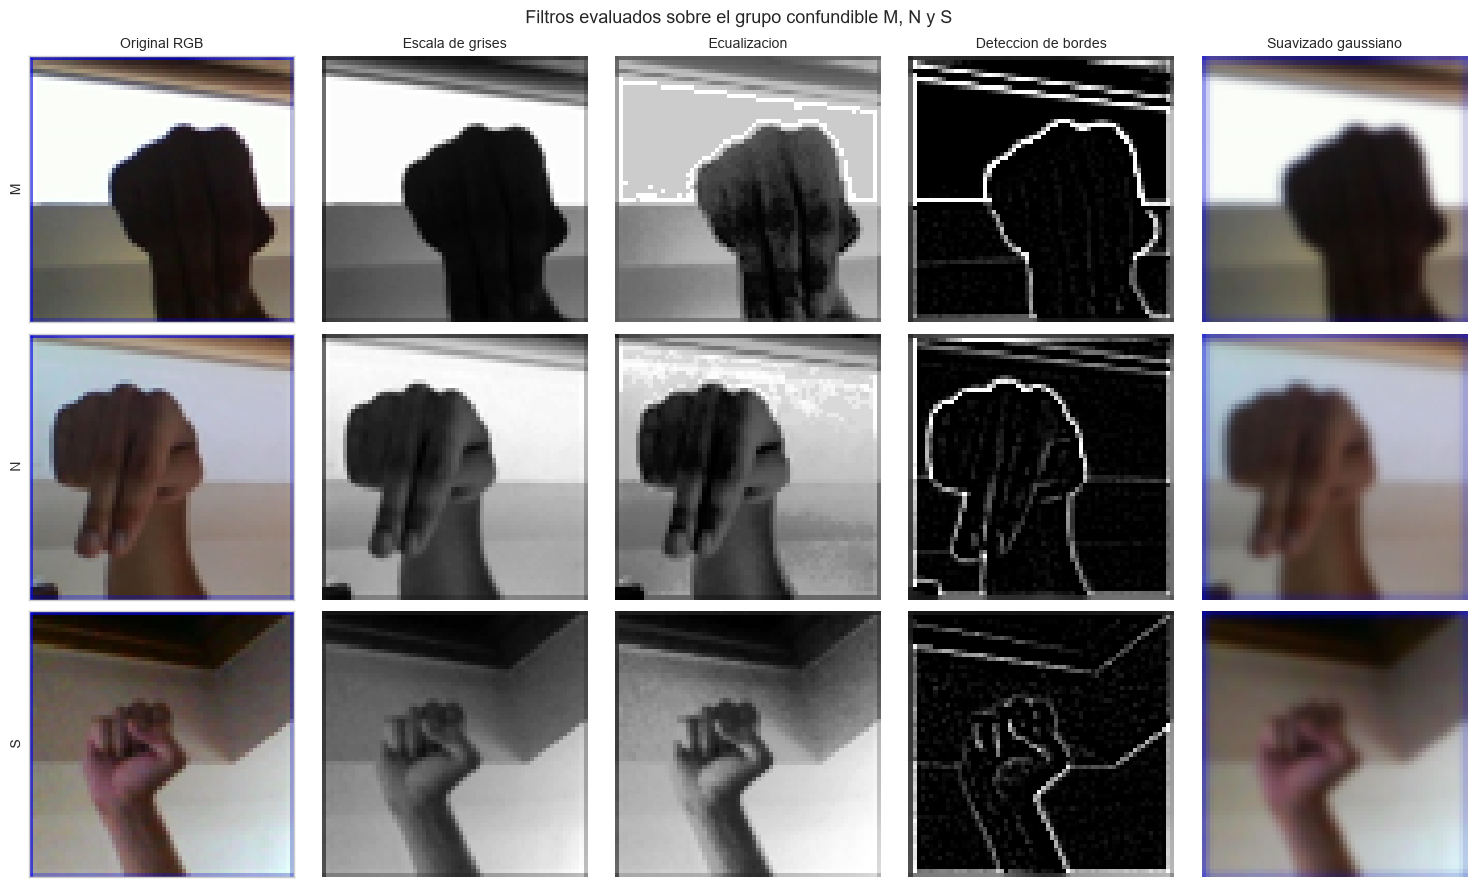

In [4]:
def a_gris(im):
    return im.convert("L")


def ecualizar(im):
    return ImageOps.equalize(im.convert("L"))


def bordes(im):
    return im.convert("L").filter(ImageFilter.FIND_EDGES)


def suavizar(im):
    return im.filter(ImageFilter.GaussianBlur(radius=1))


tratamientos = [
    ("Original RGB", lambda im: im, None),
    ("Escala de grises", a_gris, "gray"),
    ("Ecualizacion", ecualizar, "gray"),
    ("Deteccion de bordes", bordes, "gray"),
    ("Suavizado gaussiano", suavizar, None),
]

letras_demo = ["M", "N", "S"]
fig, axes = plt.subplots(len(letras_demo), len(tratamientos), figsize=(15, 9))
for i, letra in enumerate(letras_demo):
    base = Image.open(division.loc[division["clase"] == letra, "ruta"].iloc[0]).resize((LADO, LADO))
    for j, (nombre, fn, cmap) in enumerate(tratamientos):
        axes[i, j].imshow(fn(base), cmap=cmap)
        axes[i, j].axis("off")
        if i == 0:
            axes[i, j].set_title(nombre, fontsize=10)
        if j == 0:
            axes[i, j].set_ylabel(letra)
            axes[i, j].axis("on")
            axes[i, j].set_xticks([])
            axes[i, j].set_yticks([])
fig.suptitle("Filtros evaluados sobre el grupo confundible M, N y S", fontsize=13)
plt.tight_layout()
plt.show()

**Decision sobre cada filtro.**

*Escala de grises.* Se descarta como transformacion unica. Reduce la entrada a
un tercio, pero el color separa la mano del fondo y esa es informacion util
cuando la iluminacion cambia. Se conserva RGB.

*Ecualizacion de histograma.* Se descarta del pipeline base. El analisis
exploratorio mostro que la iluminacion ya es bastante uniforme porque todo se
grabo en una sola sesion, asi que la ecualizacion corrige un problema que este
dataset no tiene y amplifica el ruido del fondo. Es candidata a reevaluarse
cuando se prueben las fotos propias del ejercicio 8, donde la iluminacion si
varia.

*Deteccion de bordes.* Se descarta. Conserva el contorno pero pierde el relleno
de la palma, y en el grupo M, N y S la diferencia esta justo en la posicion del
pulgar sobre los dedos doblados, que el filtro borra.

*Suavizado gaussiano.* Se descarta del pipeline base. Las imagenes ya tienen
poco ruido y el suavizado elimina la separacion fina entre dedos. Tiene sentido
como aumento de datos, no como preprocesamiento fijo.

El pipeline final se queda con redimension a 64x64 en RGB mas normalizacion.
La ganancia esperada de los filtros no compensa la informacion que quitan.

## 3.4. Construccion de los tensores

Las imagenes se cargan una sola vez, se redimensionan y se guardan como enteros
de 8 bits. Guardar en `uint8` en lugar de `float32` usa cuatro veces menos
memoria y la conversion a flotante se hace por lote durante el entrenamiento.

In [5]:
def cargar_grupo(grupo):
    sub = division[division["grupo"] == grupo]
    X = np.zeros((len(sub), LADO, LADO, 3), dtype=np.uint8)
    y = np.zeros(len(sub), dtype=np.int64)
    for i, (_, fila) in enumerate(sub.iterrows()):
        im = Image.open(fila["ruta"]).convert("RGB").resize((LADO, LADO), Image.BILINEAR)
        X[i] = np.asarray(im, dtype=np.uint8)
        y[i] = IDX_CLASE[fila["clase"]]
    return X, y


t0 = time.time()
datos = {}
for grupo in ["train", "val", "test"]:
    X, y = cargar_grupo(grupo)
    datos[grupo] = (X, y)
    print(f"{grupo:6} X={X.shape}  y={y.shape}  {X.nbytes/1e6:.0f} MB")
print(f"tiempo total {(time.time()-t0)/60:.1f} min")

train  X=(12180, 64, 64, 3)  y=(12180,)  150 MB
val    X=(2610, 64, 64, 3)  y=(2610,)  32 MB
test   X=(2610, 64, 64, 3)  y=(2610,)  32 MB
tiempo total 10.2 min


## 3.5. Normalizacion

La media y la desviacion se calculan **solo sobre el conjunto de entrenamiento**
y se aplican a los tres grupos. Calcularlas sobre todo el dataset filtraria
informacion de validacion y prueba hacia el entrenamiento.

El acumulado se lleva en `float64` y por lotes. Sumar los casi 50 millones de
valores de cada canal en `float32` satura la precision del tipo y devuelve una
media equivocada, identica para los tres canales, que despues descentra todas
las imagenes.

In [6]:
X_train = datos["train"][0]
suma = np.zeros(3, dtype=np.float64)
suma_cuad = np.zeros(3, dtype=np.float64)
n = 0
for i in range(0, len(X_train), 1000):
    lote = X_train[i:i + 1000].astype(np.float64) / 255.0
    suma += lote.sum(axis=(0, 1, 2))
    suma_cuad += (lote ** 2).sum(axis=(0, 1, 2))
    n += lote.shape[0] * lote.shape[1] * lote.shape[2]

MEDIA = (suma / n).astype(np.float32)
DESV = np.sqrt(suma_cuad / n - (suma / n) ** 2).astype(np.float32)

print("estadisticas por canal calculadas sobre entrenamiento")
for canal, m, s in zip(["rojo", "verde", "azul"], MEDIA, DESV):
    print(f"  {canal:6} media {m:.4f}   desviacion {s:.4f}")

np.savez_compressed(
    DIR_PROC / "normalizacion.npz", media=MEDIA, desv=DESV, lado=LADO, clases=CLASES
)

estadisticas por canal calculadas sobre entrenamiento
  rojo   media 0.5209   desviacion 0.2156
  verde  media 0.5011   desviacion 0.2441
  azul   media 0.5141   desviacion 0.2551


In [7]:
for grupo, (X, y) in datos.items():
    np.savez_compressed(DIR_PROC / f"{grupo}.npz", X=X, y=y)
    print(f"guardado {grupo}.npz")

print(f"\ncarpeta {DIR_PROC.resolve()}")
print("estos archivos no se versionan, estan en el gitignore")

guardado train.npz
guardado val.npz
guardado test.npz

carpeta C:\Users\abbyd\OneDrive - Universidad del Valle de Guatemala\10mo Semestre\Data Science\Tareas\Labs\Labs_DataSci\Lab3\data\procesado
estos archivos no se versionan, estan en el gitignore


## 3.6. Dataset y DataLoader de PyTorch

El `Dataset` guarda los enteros de 8 bits y convierte a flotante normalizado en
cada acceso. El aumento de datos se pasa como argumento y queda desactivado por
defecto, porque el ejercicio 7 pide comparar contra los modelos sin aumento.

In [8]:
class DatasetASL(Dataset):
    def __init__(self, X, y, media, desv, aumento=None):
        self.X = X
        self.y = torch.from_numpy(y)
        self.media = torch.tensor(media).view(3, 1, 1)
        self.desv = torch.tensor(desv).view(3, 1, 1)
        self.aumento = aumento

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        img = torch.from_numpy(self.X[i]).permute(2, 0, 1).float() / 255.0
        if self.aumento is not None:
            img = self.aumento(img)
        return (img - self.media) / self.desv, self.y[i]


def crear_cargador(grupo, lote=128, barajar=False, aumento=None):
    X, y = datos[grupo]
    ds = DatasetASL(X, y, MEDIA, DESV, aumento)
    return DataLoader(ds, batch_size=lote, shuffle=barajar, num_workers=0)


cargador_train = crear_cargador("train", barajar=True)
xb, yb = next(iter(cargador_train))
print(f"lote de imagenes: {tuple(xb.shape)}  tipo {xb.dtype}")
print(f"lote de etiquetas: {tuple(yb.shape)}")
print(f"rango tras normalizar: {xb.min():.2f} a {xb.max():.2f}")
print(f"media del lote: {xb.mean():.4f}  desviacion: {xb.std():.4f}")

lote de imagenes: (128, 3, 64, 64)  tipo torch.float32
lote de etiquetas: (128,)
rango tras normalizar: -2.42 a 2.22
media del lote: 0.0311  desviacion: 1.0740


## 3.7. Verificacion visual del pipeline

Se revierte la normalizacion sobre un lote para confirmar que las imagenes que
recibe el modelo son las correctas y que las etiquetas corresponden.

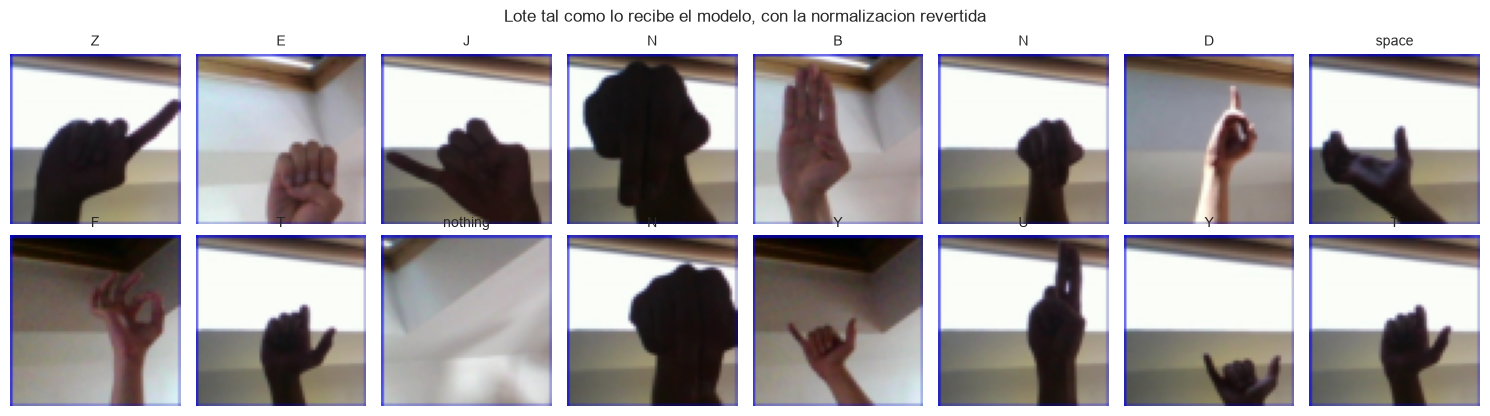

In [9]:
def desnormalizar(t):
    m = torch.tensor(MEDIA).view(3, 1, 1)
    s = torch.tensor(DESV).view(3, 1, 1)
    return (t * s + m).clamp(0, 1).permute(1, 2, 0).numpy()


fig, axes = plt.subplots(2, 8, figsize=(15, 4.2))
for ax, img, et in zip(axes.ravel(), xb, yb):
    ax.imshow(desnormalizar(img))
    ax.set_title(CLASES[et], fontsize=10)
    ax.axis("off")
fig.suptitle("Lote tal como lo recibe el modelo, con la normalizacion revertida",
             fontsize=12)
plt.tight_layout()
plt.show()

## Resumen del preprocesamiento

| Paso | Decision | Motivo |
|---|---|---|
| Submuestreo | 600 por clase, 17,400 en total | Cabe en el tiempo del laboratorio y las imagenes consecutivas son redundantes |
| Seleccion | Aleatoria sobre el rango completo | Evita concentrar un grupo en un tramo del video |
| Resolucion | 200x200 a 64x64 bilineal | 89.8 por ciento menos valores y la pose sigue siendo legible |
| Color | Se conserva RGB | El color separa la mano del fondo |
| Filtros | Ninguno en el pipeline base | Ecualizacion, bordes y suavizado quitan mas de lo que aportan |
| Escala | Division entre 255 | Lleva los valores al rango 0 a 1 |
| Normalizacion | Media y desviacion por canal | Calculadas solo con entrenamiento para no filtrar informacion |
| Almacenamiento | `uint8` en disco, flotante por lote | Cuatro veces menos memoria |
| Aumento | Desactivado por ahora | El ejercicio 7 lo compara contra esta linea base |

La entrada de los modelos queda como un tensor de 3 canales por 64 por 64,
normalizado por canal, con 29 clases de salida.